# Train XGBoost model (t+1 target)
Train an XGBoost classifier on `data/processed/xgboost_t1`, using `target_t+1` as the label and all columns except `target_t+1`, `client_nr`, and `yearmonth` as features.

Hyperparameters are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve against the business objective.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# make the models/ package importable from this notebook
sys.path.append(str(Path("models").resolve()))

from train_xgboost import (
    evaluate_all_splits,
    get_feature_columns,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,835
Validation observations: 3,790
Number of features: 30

Class distribution in training data:
  Negative: 17,507
  Positive: 1,328
  scale_pos_weight: 13.18


Best trial: 9. Best value: 0.17186: 100%|██████████| 50/50 [00:13<00:00,  3.73it/s]



Best validation PR-AUC: 0.1719
Best hyperparameters:
  learning_rate: 0.1
  max_depth: 4
  min_child_weight: 50
  subsample: 0.85
  colsample_bytree: 0.7
  gamma: 0.5
  reg_alpha: 0.01
  reg_lambda: 5
  scale_pos_weight: 13.182981927710843


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
45,45,0.171860,2026-08-30 23:31:51.227334,2026-08-30 23:31:51.550015,0 days 00:00:00.322681,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
9,9,0.171860,2026-08-30 23:31:41.554504,2026-08-30 23:31:41.777598,0 days 00:00:00.223094,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
14,14,0.171860,2026-08-30 23:31:42.749249,2026-08-30 23:31:42.990635,0 days 00:00:00.241386,0.7,0.5,0.1,4,50,0.01,5,0.85,COMPLETE
37,37,0.170768,2026-08-30 23:31:47.759353,2026-08-30 23:31:48.167758,0 days 00:00:00.408405,0.7,1.0,0.1,4,20,0.01,25,1.00,COMPLETE
22,22,0.170486,2026-08-30 23:31:44.374884,2026-08-30 23:31:44.609531,0 days 00:00:00.234647,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
17,17,0.170486,2026-08-30 23:31:43.312206,2026-08-30 23:31:43.551683,0 days 00:00:00.239477,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
33,33,0.170486,2026-08-30 23:31:46.800830,2026-08-30 23:31:47.047324,0 days 00:00:00.246494,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
32,32,0.170486,2026-08-30 23:31:46.540574,2026-08-30 23:31:46.797507,0 days 00:00:00.256933,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
31,31,0.170486,2026-08-30 23:31:46.267408,2026-08-30 23:31:46.539468,0 days 00:00:00.272060,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE
26,26,0.170486,2026-08-30 23:31:45.255167,2026-08-30 23:31:45.496446,0 days 00:00:00.241279,0.7,0.5,0.1,4,50,0.01,50,0.85,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

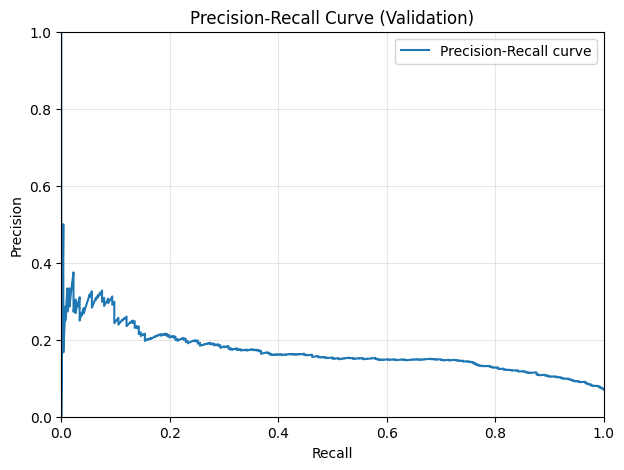

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title="Precision-Recall Curve (Validation)",
)

In [5]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.35].head(20)

,threshold,precision,recall
3752,0.796134,0.352941,0.022556
3753,0.796437,0.375000,0.022556
3767,0.818232,0.500000,0.003759


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

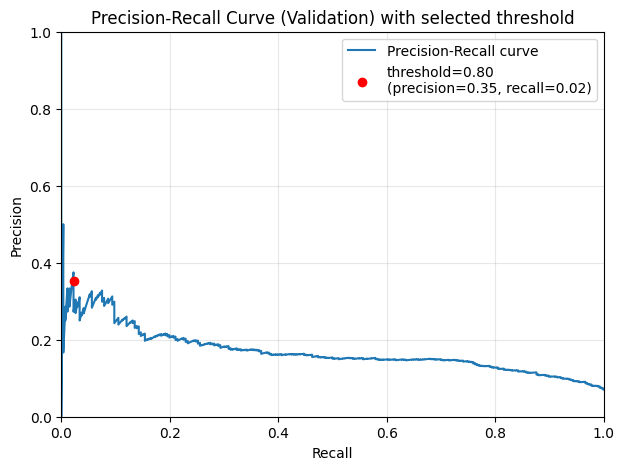

In [6]:
SELECTED_THRESHOLD = 0.796134

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title="Precision-Recall Curve (Validation) with selected threshold",
);

## Final evaluation

In [7]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.222557,0.400000,0.013554,0.026220,0.433333,0.029367
val,0.171860,0.375000,0.022556,0.042553,0.288889,0.097744
test,0.146609,0.245283,0.034946,0.061176,0.222222,0.053763


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [8]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\xgboost_t1.joblib


WindowsPath('models/artifacts/xgboost_t1.joblib')